In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [2]:
# Set style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [4]:
# Load clean fact table
fact = pd.read_csv("../data/processed/fact_sessions_clean.csv")

# Convert date column
fact['date'] = pd.to_datetime(fact['date'])

print(f"Shape: {fact.shape}")
print(f"Date range: {fact['date'].min()} to {fact['date'].max()}")
print(f"Overall conversion rate: {fact['is_converted'].mean():.2%}")
print(f"Columns: {fact.columns.tolist()}")

Shape: (472871, 19)
Date range: 2012-03-19 00:00:00 to 2015-03-19 00:00:00
Overall conversion rate: 6.83%
Columns: ['website_session_id', 'created_at', 'user_id', 'is_repeat_session', 'utm_source', 'utm_campaign', 'utm_content', 'device_type', 'http_referer', 'date', 'hour', 'day_of_week', 'month', 'weekend', 'channel', 'order_id', 'price_usd', 'is_converted', 'net_revenue_usd']


In [5]:
daily = fact.groupby('date').agg(
    sessions=('is_converted', 'count'),
    orders=('is_converted', 'sum'),
    revenue=('price_usd', 'sum')
).reset_index()

daily['conv_rate'] = daily['orders'] / daily['sessions']
daily['revenue_per_session'] = daily['revenue'] / daily['sessions']
daily['aov'] = daily['revenue'] / daily['orders']

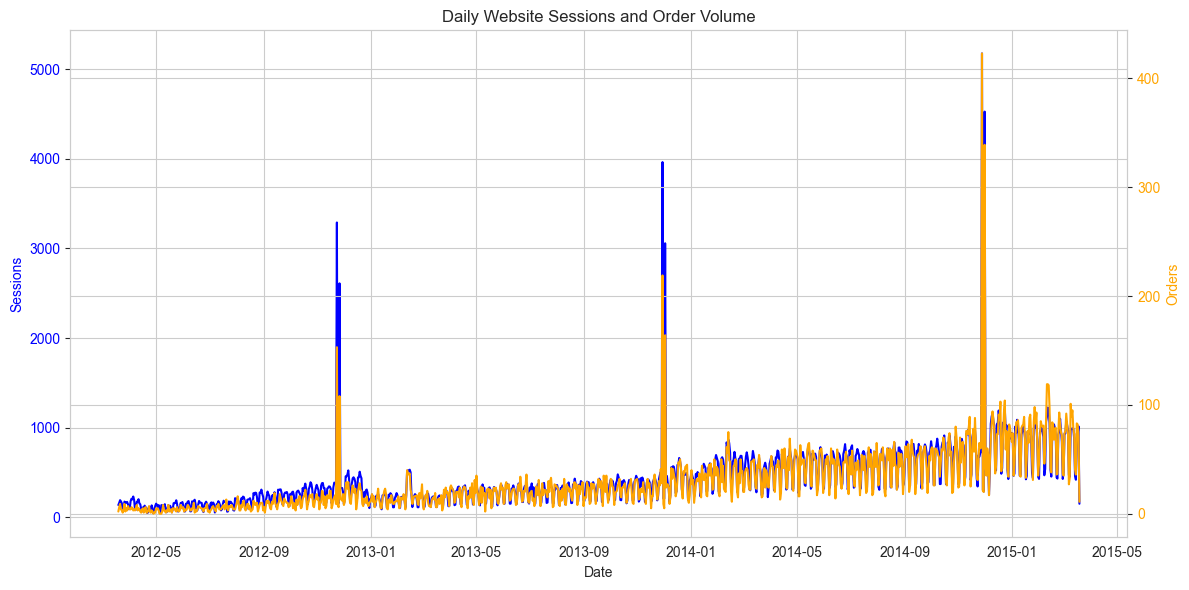

In [6]:
fig, ax1 = plt.subplots()
ax1.plot(daily['date'], daily['sessions'], color='blue', label='Sessions')
ax1.set_xlabel('Date')
ax1.set_ylabel('Sessions', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()
ax2.plot(daily['date'], daily['orders'], color='orange', label='Orders')
ax2.set_ylabel('Orders', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

plt.title('Daily Website Sessions and Order Volume')
fig.tight_layout()
plt.savefig('../docs/trend_sessions_orders.png')
plt.show()

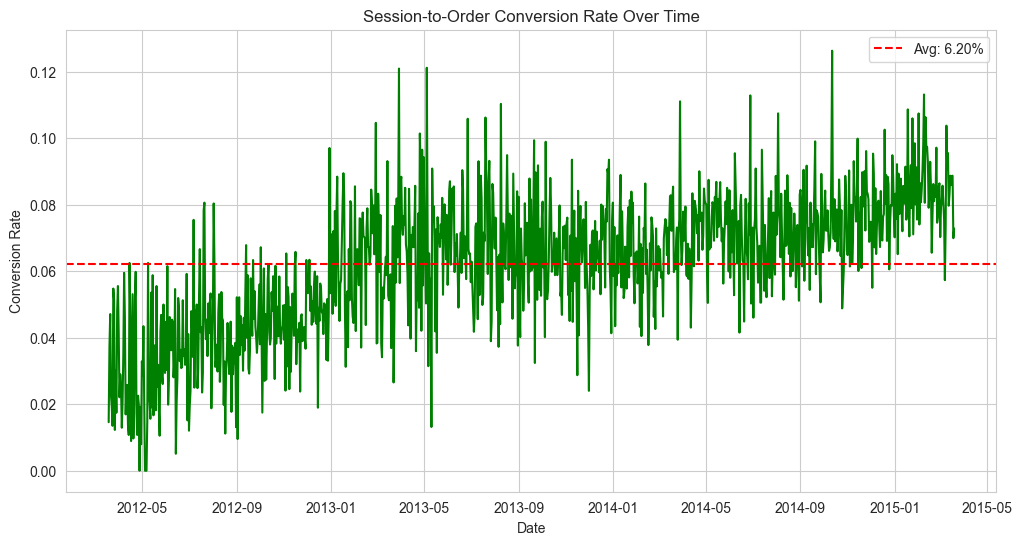

In [7]:
plt.figure()
plt.plot(daily['date'], daily['conv_rate'], color='green')
plt.axhline(daily['conv_rate'].mean(), color='red', linestyle='--', label=f"Avg: {daily['conv_rate'].mean():.2%}")
plt.xlabel('Date')
plt.ylabel('Conversion Rate')
plt.title('Session-to-Order Conversion Rate Over Time')
plt.legend()
plt.savefig('../docs/conversion_rate_trend.png')
plt.show()

C:\Users\conta\AppData\Local\Temp\ipykernel_2004\2584059858.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=channel_perf, x='channel', y='revenue', palette='viridis')


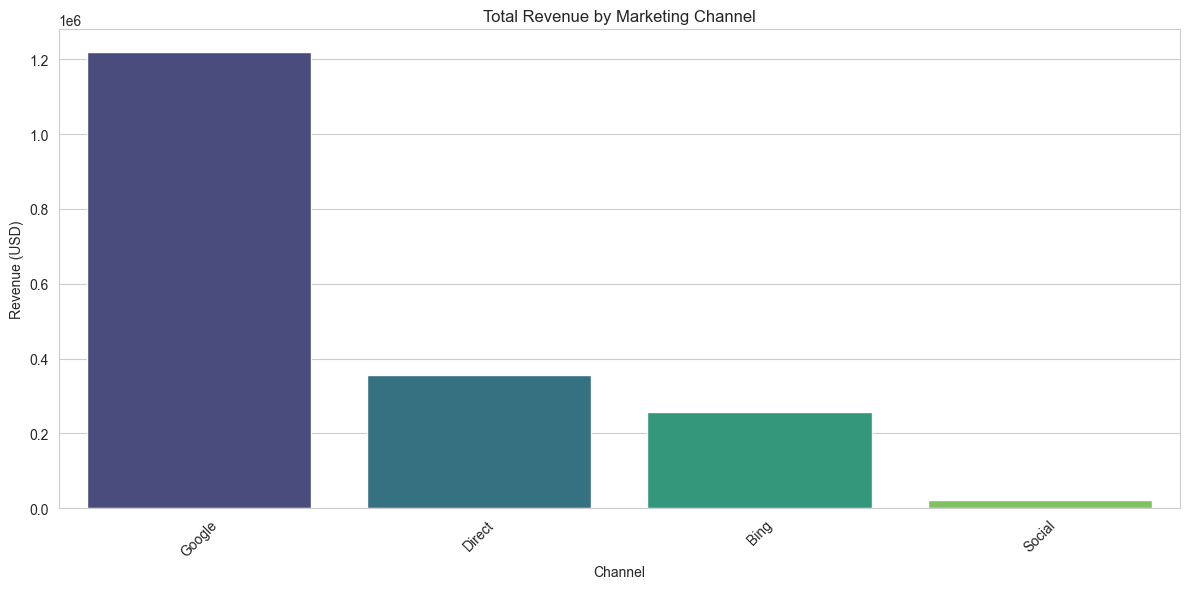

  channel  sessions  orders  conv_rate  revenue_per_session
2  Google    316035   21333   0.067502             3.857454
1  Direct     83328    6118   0.073421             4.269156
0    Bing     62823    4519   0.071932             4.092655
3  Social     10685     343   0.032101             1.986668


In [8]:
channel_perf = fact.groupby('channel').agg(
    sessions=('is_converted', 'count'),
    orders=('is_converted', 'sum'),
    revenue=('net_revenue_usd', 'sum')
).reset_index()
channel_perf['conv_rate'] = channel_perf['orders'] / channel_perf['sessions']
channel_perf['revenue_per_session'] = channel_perf['revenue'] / channel_perf['sessions']
channel_perf = channel_perf.sort_values('revenue', ascending=False)

plt.figure()
sns.barplot(data=channel_perf, x='channel', y='revenue', palette='viridis')
plt.title('Total Revenue by Marketing Channel')
plt.xlabel('Channel')
plt.ylabel('Revenue (USD)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../docs/revenue_by_channel.png')
plt.show()

print(channel_perf[['channel', 'sessions', 'orders', 'conv_rate', 'revenue_per_session']])

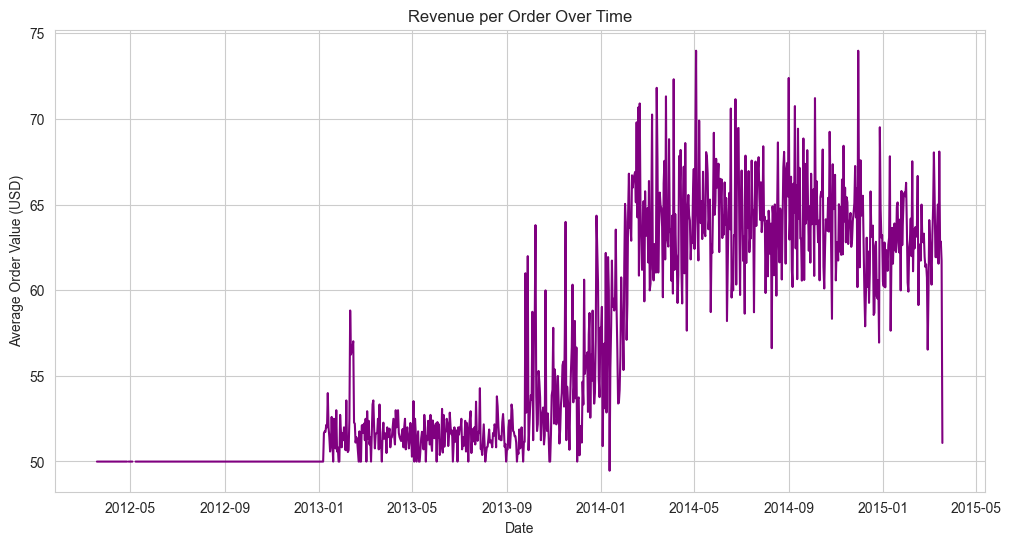

In [9]:
plt.figure()
plt.plot(daily['date'], daily['aov'], color='purple')
plt.xlabel('Date')
plt.ylabel('Average Order Value (USD)')
plt.title('Revenue per Order Over Time')
plt.savefig('../docs/aov_trend.png')
plt.show()

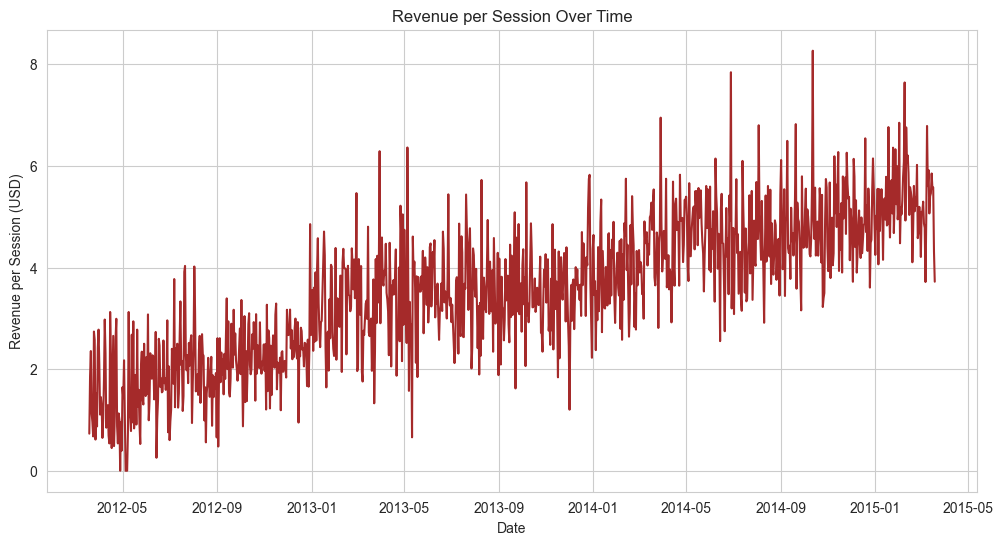

In [10]:
plt.figure()
plt.plot(daily['date'], daily['revenue_per_session'], color='brown')
plt.xlabel('Date')
plt.ylabel('Revenue per Session (USD)')
plt.title('Revenue per Session Over Time')
plt.savefig('../docs/rps_trend.png')
plt.show()